---
# 24 Hours of Le Mans — Race Analysis and Insights
### *Jordan Meulink*

---

## Introduction

The 24 Hours of Le Mans is the world's oldest active sports car race in endurance racing,
held annually on the Circuit de la Sarthe in Le Mans, France. First run in 1923, it stands
alongside the Indianapolis 500 and the Monaco Grand Prix as one of motorsport's "Triple Crown"
events, a race that pushes cars and drivers to their absolute limits across a full day
and night of competition.

This project examines the 2023 edition of the race using hour-by-hour data capturing
every car's position, lap times, and pit stop activity across all 24 hours of
competition. The dataset covers 62 cars across four categories — Hypercar, LMP2, LMGTE Am, and
Innovative Car — offering a granular view of how the race unfolded from the opening lap to the
checkered flag.

**The notebook is structured around three acts:**
- Act 1 Who was on the grid, what were they driving, and how was the
  field composed across categories?
- Act 2 How did positions, pit stop strategy, and lap times evolve across
  the race? What does the data reveal about team strategy and car performance?
- Act 3 Who finished, who retired, and what does the data tell us
  about reliability, engineering, and the razor-thin margins that decided the outcome?

---

In [105]:
import pandas as pd

# Load the dataset 
df = pd.read_csv('hourbyhourraceanalysis.csv', encoding='latin1')

print("Raw CSV Overview")
print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:\n{df.head()}")

Raw CSV Overview
Shape: (1486, 15)

Column names:
['S.No', 'Hour', 'Car No.', 'Team', 'Drivers', 'Car', 'Category', 'Tyres  ', 'Laps', 'Total Time', 'Pitstops', 'Best Lap Number', 'Best LapTime', 'Best Lap Kph', 'Status']

Data types:
S.No                 int64
Hour                 int64
Car No.              int64
Team                   str
Drivers                str
Car                    str
Category               str
Tyres                  str
Laps                 int64
Total Time             str
Pitstops             int64
Best Lap Number    float64
Best LapTime           str
Best Lap Kph       float64
Status                 str
dtype: object

First 5 rows:
   S.No  Hour  Car No.                       Team  \
0     1     1        8        Toyota Gazoo Racing   
1     2     1       51           Ferrari AF Corse   
2     3     1        7        Toyota Gazoo Racing   
3     4     1       75  Porsche Penske Motorsport   
4     5     1        6  Porsche Penske Motorsport   

            

In [106]:
# Clean column names
# Strip leading/trailing whitespace from all column names
df.columns = df.columns.str.strip()

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['S.No', 'Hour', 'Car No.', 'Team', 'Drivers', 'Car', 'Category', 'Tyres', 'Laps', 'Total Time', 'Pitstops', 'Best Lap Number', 'Best LapTime', 'Best Lap Kph', 'Status']


In [107]:
# Clean string columns 
# Strip whitespace from all string/object columns
str_cols = df.select_dtypes(include=['object', 'str']).columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

# Standardize the Category column.
# The raw data contains three HYPERCAR variants: 'HYPERCAR', 'HYPERCAR ' (trailing space),
# and 'HYPERCAR H'. The trailing-space variant is clearly a data entry error.
# 
# 'HYPERCAR H' appears only 3 times (Hours 18, 19, 22) for Car #311 (Cadillac V-Series.R)
# and Car #6 (Porsche 963). Researched whether this was meant to denote Hybrid Hypercars
# as a distinct subcategory. While both cars are indeed hybrid-powered, so are several other
# Hypercars in the field (Toyota GR010, Ferrari 499P, Peugeot 9X8) which are all labeled
# simply 'HYPERCAR'. Concluded that 'HYPERCAR H' is a data entry inconsistency rather
# than an intentional distinction, and have collapsed all three variants into 'HYPERCAR'.
print("Category values before cleaning:")
print(df['Category'].value_counts())

df['Category'] = df['Category'].replace({'HYPERCAR ': 'HYPERCAR', 'HYPERCAR H': 'HYPERCAR'})

print("\nCategory values after cleaning:")
print(df['Category'].value_counts())

Category values before cleaning:
Category
LMP2              575
LMGTE Am          504
HYPERCAR          380
INNOVATIVE CAR     24
HYPERCAR H          3
Name: count, dtype: int64

Category values after cleaning:
Category
LMP2              575
LMGTE Am          504
HYPERCAR          383
INNOVATIVE CAR     24
Name: count, dtype: int64


In [108]:
# Fix missing car name for Car #28 (JOTA) — confirmed Oreca 07 - Gibson based on team/category
df.loc[df['Car No.'] == 28, 'Car'] = df.loc[df['Car No.'] == 28, 'Car'].fillna('Oreca 07 - Gibson')

print("Verification:")
print(df[df['Car No.'] == 28][['Hour', 'Car No.', 'Team', 'Car']].tail(3).to_string())

Verification:
      Hour  Car No.  Team                Car
1326    22       28  JOTA  Oreca 07 - Gibson
1388    23       28  JOTA  Oreca 07 - Gibson
1448    24       28  JOTA  Oreca 07 - Gibson


In [109]:
# Step 3: Parse time columns
# Convert 'Best LapTime' (format MM:SS.S) to total seconds for numeric analysis
def parse_laptime(t):
    try:
        parts = t.strip().split(':')
        return int(parts[0]) * 60 + float(parts[1])
    except:
        return None

df['Best LapTime (s)'] = df['Best LapTime'].apply(parse_laptime)

print("Sample lap time conversions:")
print(df[['Best LapTime', 'Best LapTime (s)']].dropna().head(10))

Sample lap time conversions:
  Best LapTime  Best LapTime (s)
0      03:29.7             209.7
1      03:29.1             209.1
2      03:30.0             210.0
3      03:29.9             209.9
4      03:30.0             210.0
5      03:30.1             210.1
6      03:30.2             210.2
7      03:30.1             210.1
8      03:29.5             209.5
9      03:29.7             209.7


In [110]:
# Clean up Status and numeric columns 
# Confirm Status values are clean
print("Status values:", df['Status'].unique())

# Convert Best Lap Number to integer where possible
df['Best Lap Number'] = pd.to_numeric(df['Best Lap Number'], errors='coerce').astype('Int64')

print(f"\nMissing values per column:\n{df.isnull().sum()}")

Status values: <StringArray>
['Running', 'Retired']
Length: 2, dtype: str

Missing values per column:
S.No                0
Hour                0
Car No.             0
Team                0
Drivers             0
Car                 0
Category            0
Tyres               1
Laps                0
Total Time          0
Pitstops            0
Best Lap Number     1
Best LapTime        1
Best Lap Kph        1
Status              0
Best LapTime (s)    1
dtype: int64


In [111]:
# Fix data entry errors
# Car No. 0 appears once at Hour 10 for Peugeot TotalEnergies (Duval/Menezes/Müller)
# This is a single erroneous entry and has been corrected 
df.loc[df['Car No.'] == 0, 'Car No.'] = 94

print("Verification — Car #94 at Hour 10 after fix:")
print(df[(df['Car No.'] == 94) & (df['Hour'] == 10)][['Hour', 'Car No.', 'Team', 'Drivers', 'Laps', 'Pitstops']].to_string())

Verification — Car #94 at Hour 10 after fix:
     Hour  Car No.                   Team                             Drivers  Laps  Pitstops
558    10       94  Peugeot TotalEnergies  L. DUVAL / G. MENEZES / N. MÃLLER   123        11


In [112]:
# Final cleaned dataset summary
print("Cleaned Data Overview")
print(f"Shape: {df.shape}")
print(f"\nCategories: {df['Category'].unique()}")
print(f"Hours covered: {df['Hour'].min()} to {df['Hour'].max()}")
print(f"Unique cars: {df['Car No.'].nunique()}")
print(f"\nSample cleaned data:\n{df.head()}")

Cleaned Data Overview
Shape: (1486, 16)

Categories: <StringArray>
['HYPERCAR', 'LMP2', 'INNOVATIVE CAR', 'LMGTE Am']
Length: 4, dtype: str
Hours covered: 1 to 24
Unique cars: 62

Sample cleaned data:
   S.No  Hour  Car No.                       Team  \
0     1     1        8        Toyota Gazoo Racing   
1     2     1       51           Ferrari AF Corse   
2     3     1        7        Toyota Gazoo Racing   
3     4     1       75  Porsche Penske Motorsport   
4     5     1        6  Porsche Penske Motorsport   

                                     Drivers                  Car  Category  \
0        S. BUEMI / B. HARTLEY / R. HIRAKAWA  Toyota GR010 HYBRID  HYPERCAR   
1  A. PIER GUIDI / J. CALADO / A. GIOVINAZZI         Ferrari 499P  HYPERCAR   
2        M. CONWAY / K. KOBAYASHI / J. LOPEZ  Toyota GR010 HYBRID  HYPERCAR   
3            F. NASR / M. JAMINET / N. TANDY          Porsche 963  HYPERCAR   
4       K. ESTRE / A. LOTTERER / L. VANTHOOR          Porsche 963  HYPERCAR   

  Tyr

## Data Cleaning Findings

During the cleaning process, several data inconsistencies were identified and corrected:

- Car #0 appeared once at Hour 10 for Peugeot TotalEnergies. Cross-referencing the dataset
confirmed this was a data entry error for Car #94 (Duval/Menezes/Müller) and was corrected.

- 'HYPERCAR H' appeared only 3 times in the dataset (Hours 18, 19, and 22) for Car #311
(Cadillac V-Series.R) and Car #6 (Porsche 963). After research, this was confirmed to be a data 
entry inconsistency rather than an intentional distinction — all other hybrid Hypercars in the 
field are labeled simply 'HYPERCAR'.

- Car #28 (JOTA, Heinemeier-Hansson/Rasmussen/Fittipaldi) had a missing car name in its
Hour 24 entry. Based on the team and category, this was confirmed to be an Oreca 07 - Gibson.

---
# Act 1

The 24 Hours of Le Mans tells a story through its starting grid. This act introduces the full field — the teams, the cars, and the categories that will battle across the next 24 hours. From the cutting-edge Hypercar class to the privateer spirit of LMP2 and LMGTE Am, the starting grid sets the stage for everything that follows.

---

In [113]:
# Starting Grid 
# Filter to Hour 1 only — this represents the starting grid. 
starting_grid = df[df['Hour'] == 1].copy()

# Select and reorder the relevant columns for the starting grid
starting_grid = starting_grid[['Car No.', 'Team', 'Drivers', 'Car', 'Category', 'Tyres']].reset_index(drop=True)

print(f"Total starting cars: {len(starting_grid)}")
print(f"\nCars by category:")
print(starting_grid['Category'].value_counts())
print(f"\nStarting grid preview:\n{starting_grid.head(10)}")

# Export to CSV for Tableau
starting_grid.to_csv('starting_grid.csv', index=False)
print("\nExported to starting_grid.csv")

Total starting cars: 62

Cars by category:
Category
LMP2              24
LMGTE Am          21
HYPERCAR          16
INNOVATIVE CAR     1
Name: count, dtype: int64

Starting grid preview:
   Car No.                       Team  \
0        8        Toyota Gazoo Racing   
1       51           Ferrari AF Corse   
2        7        Toyota Gazoo Racing   
3       75  Porsche Penske Motorsport   
4        6  Porsche Penske Motorsport   
5        5  Porsche Penske Motorsport   
6        2            Cadillac Racing   
7       93      Peugeot TotalEnergies   
8       38            Hertz Team JOTA   
9       94      Peugeot TotalEnergies   

                                       Drivers                  Car  Category  \
0          S. BUEMI / B. HARTLEY / R. HIRAKAWA  Toyota GR010 HYBRID  HYPERCAR   
1    A. PIER GUIDI / J. CALADO / A. GIOVINAZZI         Ferrari 499P  HYPERCAR   
2          M. CONWAY / K. KOBAYASHI / J. LOPEZ  Toyota GR010 HYBRID  HYPERCAR   
3              F. NASR / M. JAMINET / 


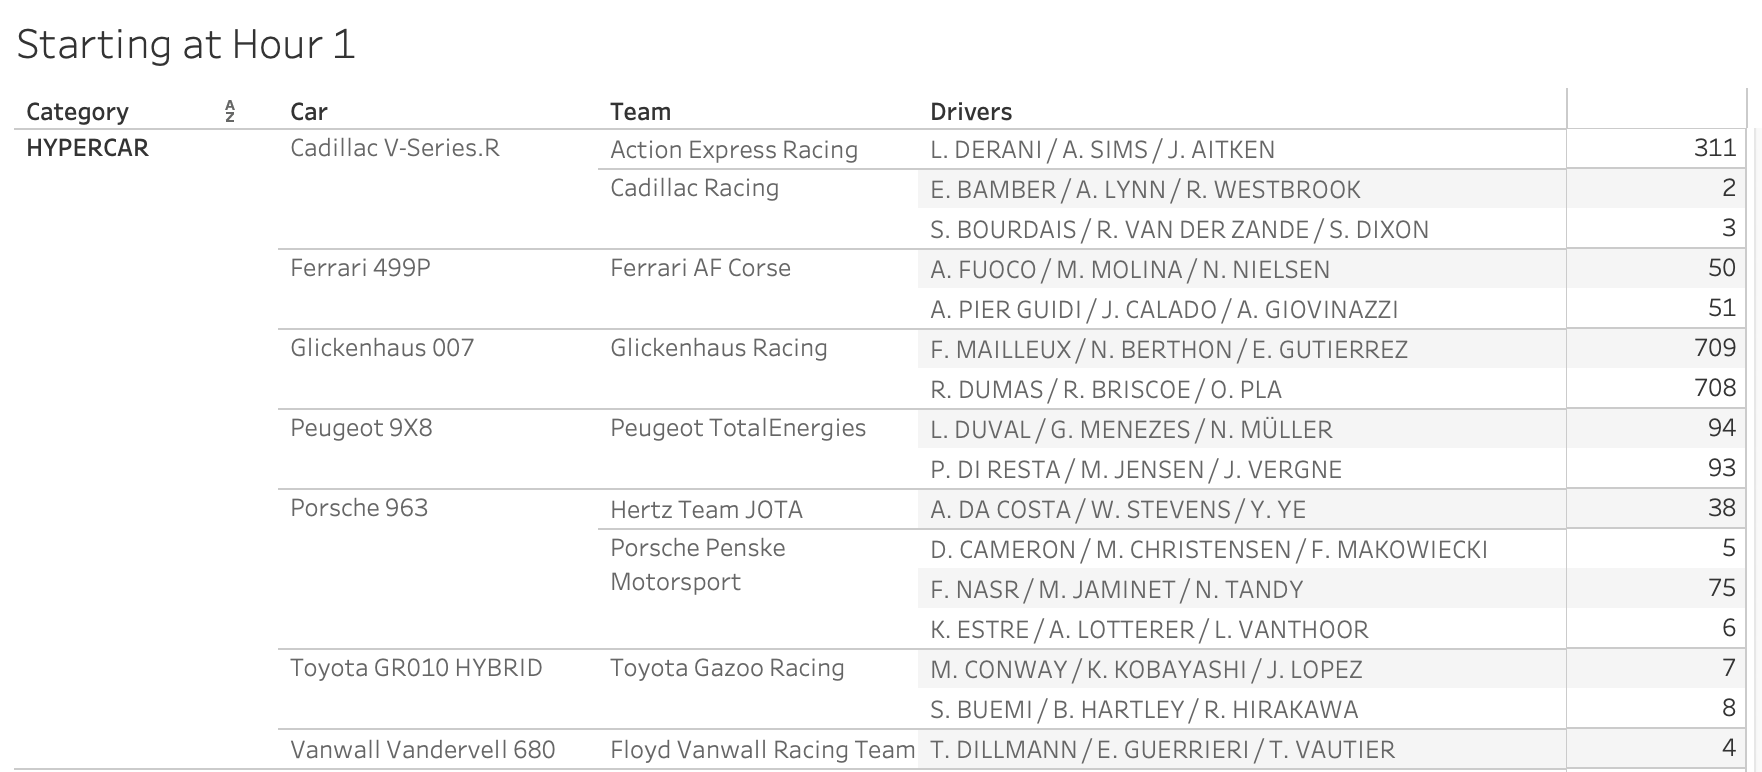

In [114]:
from IPython.display import HTML, Image
import base64

with open('starting_grid.png', 'rb') as f:
    img_data = base64.b64encode(f.read()).decode()

HTML(f'''
<a href="https://public.tableau.com/views/202324HoursofLeMans/StartingGrid" target="_blank">
  <img src="data:image/png;base64,{img_data}" width="900"/>
  <br><i>Click to view interactive version</i>
</a>
''')

In [115]:
import requests
from bs4 import BeautifulSoup
import re

# Car Specs from Wikipedia 
car_wikipedia_urls = {
    'Toyota GR010 HYBRID':     'https://en.wikipedia.org/wiki/Toyota_GR010',
    'Ferrari 499P':            'https://en.wikipedia.org/wiki/Ferrari_499P',
    'Porsche 963':             'https://en.wikipedia.org/wiki/Porsche_963',
    'Cadillac V-Series.R':     'https://en.wikipedia.org/wiki/Cadillac_V-Series.R',
    'Peugeot 9X8':             'https://en.wikipedia.org/wiki/Peugeot_9X8',
    'Glickenhaus 007':         'https://en.wikipedia.org/wiki/Glickenhaus_SCG_007_LMH',
    'Vanwall Vandervell 680':  'https://en.wikipedia.org/wiki/Vanwall_Vandervell_680',
    'Porsche 911 RSR - 19':    'https://en.wikipedia.org/wiki/Porsche_911_RSR',
    'Ferrari 488 GTE Evo':     'https://en.wikipedia.org/wiki/Ferrari_488_GTE',
    'Chevrolet Corvette C8.R': 'https://en.wikipedia.org/wiki/Chevrolet_Corvette_C8.R',
    'Oreca 07 - Gibson':       'https://en.wikipedia.org/wiki/Oreca_07',
    'Aston Martin Vantage AMR':'https://en.wikipedia.org/wiki/Aston_Martin_Vantage_GTE_(2018)',
}

# Hardcoded entry for Chevrolet Camaro ZL1 (no Wikipedia page exists)
# Specs sourced from NASCAR/Hendrick Motorsports official release and 24h-lemans.com
camaro_hardcoded = {
    'Car': 'Chevrolet Camaro ZL1',
    'Description': (
        'The Chevrolet Camaro ZL1 competed at the 2023 24 Hours of Le Mans as the Garage 56 '
        'entry — a special class reserved for innovative vehicles. Built by Hendrick Motorsports '
        'in partnership with NASCAR, Chevrolet, and Goodyear, it was a near-stock NASCAR Cup '
        'Series car adapted for endurance racing, driven by Jimmie Johnson, Jenson Button, and '
        'Mike Rockenfeller. It finished 39th overall after a late gearbox issue.'
    ),
    'Specs': {
        'Engine':       'Chevrolet R07 5.5 L V8 naturally aspirated',
        'Power':        '680 hp',
        'Weight':       '2,960 lbs / 1,342 kg (Le Mans spec, reduced from 3,200 lbs)',
        'Transmission': 'Sequential manual',
        'Category':     'Innovative Car (Garage 56)',
        'Drivers':      'J. Johnson / J. Button / M. Rockenfeller',
    }
}

def scrape_car_info(car_name, url):
    try:
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
        response = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(response.text, 'html.parser')

        # Get first meaningful paragraph as description
        intro = soup.find('div', class_='mw-parser-output')
        description = ''
        if intro:
            for p in intro.find_all('p'):
                text = p.get_text().strip()
                if len(text) > 100:
                    description = text
                    break

        if not description:
            description = 'No description available.'

        # Get specs from infobox if available
        specs = {}
        infobox = soup.find('table', class_='infobox')
        if infobox:
            for row in infobox.find_all('tr'):
                cells = row.find_all(['th', 'td'])
                if len(cells) == 2:
                    key = cells[0].get_text().strip()
                    value = cells[1].get_text().strip()
                    specs[key] = value

        return {'Car': car_name, 'Description': description, 'Specs': specs}

    except Exception as e:
        return {'Car': car_name, 'Description': f'Error: {e}', 'Specs': {}}

# Scrape all cars with Wikipedia pages
car_info = []
for car, url in car_wikipedia_urls.items():
    print(f"Scraping {car}...")
    info = scrape_car_info(car, url)
    car_info.append(info)
    status = '✓' if info['Description'] not in ('No description available.',) and 'Error' not in info['Description'] else '✗'
    print(f"  {status} {info['Description'][:100]}...")

# Append hardcoded Camaro entry
car_info.append(camaro_hardcoded)
print(f"\n  ✓ (hardcoded) {camaro_hardcoded['Description'][:100]}...")

success = sum(1 for c in car_info if 'Error' not in c['Description'] and c['Description'] != 'No description available.')
print(f"\nSuccessfully scraped/loaded {success}/{len(car_info)} cars")

Scraping Toyota GR010 HYBRID...
  ✓ The Toyota GR010 Hybrid is a sports prototype racing car developed by Toyota Gazoo Racing Europe for...
Scraping Ferrari 499P...
  ✓ The Ferrari 499P (project code F255)[4] is a sports prototype built by Scuderia Ferrari to compete i...
Scraping Porsche 963...
  ✓ The Porsche 963 (Type 9R0) is an LMDh sports prototype racing car designed by Porsche and built by M...
Scraping Cadillac V-Series.R...
  ✓ The Cadillac V-Series.R, originally named the Cadillac V-LMDh, is a sports prototype racing car desi...
Scraping Peugeot 9X8...
  ✓ The Peugeot 9X8 is a sports prototype racing car built by French car manufacturer Peugeot for the Le...
Scraping Glickenhaus 007...
  ✓ The Scuderia Cameron Glickenhaus SCG 007 LMH is a sports prototype built by American manufacturer Sc...
Scraping Vanwall Vandervell 680...
  ✓ The Vanwall Vandervell 680 is a sports prototype racing car designed and built by Vanwall Racing Tea...
Scraping Porsche 911 RSR - 19...
  ✓ The Por

In [116]:
import re

# Display Car Info Neatly 
for car in car_info:
    print(f"\n{'='*60}")
    print(f"Car: {car['Car']}")
    # Remove Wikipedia citation brackets e.g. [1], [23]
    description = re.sub(r'\[\d+\]', '', car['Description']).strip()
    print(f"Description: {description}")
    if car['Specs']:
        print("Key Specs:")
        relevant_keys = ['Engine', 'Power', 'Transmission', 'Weight', 'Top speed']
        for key in relevant_keys:
            if key in car['Specs']:
                print(f"  {key}: {car['Specs'][key]}")


Car: Toyota GR010 HYBRID
Description: The Toyota GR010 Hybrid is a sports prototype racing car developed by Toyota Gazoo Racing Europe for the 2021 Le Mans Hypercar rules in the FIA World Endurance Championship. The car is the successor of the Toyota TS050 Hybrid, which competed in the WEC from 2016 to 2020, achieving two double WEC world titles and three straight victories at the 24 Hours of Le Mans from 2018 to 2020. The GR010 Hybrid was revealed online on 15 January 2021. A bodywork update saw the car renamed to Toyota TR010 Hybrid in 2026, in line with the team's rebrand to Toyota Racing.
Key Specs:
  Engine: Toyota H8909 3.5 L (214 cu in) 90-degree V6 twin-turbo mid, longitudinally mounted with 4WD system
  Power: 500 kW (671 hp) (ICE)
200 kW (268 hp) (electric motors)
  Transmission: Toyota with Aisin internals transverse 7-speed + 1 reverse sequential semi-automatic
  Weight: 1,040 kg (2,293 lb)

Car: Ferrari 499P
Description: The Ferrari 499P (project code F255) is a sports pr

In [117]:
# Act 2:

# Position by hour
# Rank cars by laps completed at each hour (more laps = higher position)
# For ties, use total time as a tiebreaker (less time = higher position)

import warnings
warnings.filterwarnings('ignore', category=FutureWarning,)
# FutureWarning: pandas groupby behavior change in future version — current behavior is correct for our use case
warnings.filterwarnings('ignore', category=UserWarning,)
# UserWarning: boolean series index reindexing — handled by combined & filter elsewhere in the code

df['Total Time'] = df['Total Time'].str.strip()

def rank_by_hour(group):
    group = group.copy()
    sorted_group = group.sort_values(
        by=['Laps', 'Total Time'],
        ascending=[False, True]
    ).reset_index(drop=True)
    sorted_group['Position'] = sorted_group.index + 1
    return sorted_group

hourly_positions = (
    df.groupby(['Hour', 'Category'], group_keys=True)
    .apply(rank_by_hour)
    .reset_index(level=['Hour', 'Category'])
    .reset_index(drop=True)
)

# Keep only the columns relevant for position tracking
position_df = hourly_positions[['Hour', 'Car No.', 'Team', 'Drivers', 'Car',
                                 'Category', 'Laps', 'Total Time', 'Position']].copy()

print("Hourly Position Data")
print(f"Shape: {position_df.shape}")
print(f"\nSample - Hour 1 leaders by category:\n")
print(position_df[position_df['Position'] == 1][
    position_df['Hour'] == 1][['Hour', 'Category', 'Car No.', 'Team', 'Laps']].to_string())

# Export for Tableau
position_df

Hourly Position Data
Shape: (1486, 9)

Sample - Hour 1 leaders by category:

    Hour        Category  Car No.                  Team  Laps
0      1        HYPERCAR        8   Toyota Gazoo Racing    12
16     1  INNOVATIVE CAR       24  Hendrick Motorsports    12
17     1        LMGTE Am       56        Project 1 - AO    12
38     1            LMP2       48            IDEC Sport    12


,Hour,Car No.,Team,Drivers,Car,Category,Laps,Total Time,Position
0,1,8,Toyota Gazoo Racing,S. BUEMI / B. HARTLEY / R. HIRAKAWA,Toyota GR010 HYBRID,HYPERCAR,12,01:01:15,1
1,1,51,Ferrari AF Corse,A. PIER GUIDI / J. CALADO / A. GIOVINAZZI,Ferrari 499P,HYPERCAR,12,01:01:19,2
2,1,7,Toyota Gazoo Racing,M. CONWAY / K. KOBAYASHI / J. LOPEZ,Toyota GR010 HYBRID,HYPERCAR,12,01:01:21,3
3,1,75,Porsche Penske Motorsport,F. NASR / M. JAMINET / N. TANDY,Porsche 963,HYPERCAR,12,01:01:22,4
4,1,6,Porsche Penske Motorsport,K. ESTRE / A. LOTTERER / L. VANTHOOR,Porsche 963,HYPERCAR,12,01:01:23,5
...,...,...,...,...,...,...,...,...,...
1481,24,47,COOL Racing,DE GÉRUS / V. LOMKO / S. PAGENAUD,Oreca 07 - Gibson,LMP2,158,12:41:04,19
1482,24,32,Inter Europol Competition,M. KVAMME / J. MAGNUSSEN / A. FJORDBACH,Oreca 07 - Gibson,LMP2,117,11:07:56,20
1483,24,63,Prema Racing,D. PIN / D. KVYAT / M. BORTOLOTTI,Oreca 07 - Gibson,LMP2,113,09:35:29,21
1484,24,923,Racing Team Turkey,S. YOLUC / T. GAMBLE / D. VANTHOOR,Oreca 07 - Gibson,LMP2,87,07:50:02,22


---
# Act 2:

The race comes alive in Act 2. Every hour brings new position changes, pit stop calls, and lap time battles. This act tracks the ebb and flow of competition across all 24 hours, revealing which teams raced conservatively, which pushed from the start, and how strategy shaped the outcome as much as outright speed.

---

In [118]:
# Pit stop strategy by hour
# Track cumulative pit stops per car across all 24 hours
pitstop_df = df[['Hour', 'Car No.', 'Team', 'Car', 'Category', 'Pitstops']].copy()

# Calculate pit stops made each hour 
pitstop_df = pitstop_df.sort_values(by=['Car No.', 'Hour'])
pitstop_df['Pitstops This Hour'] = pitstop_df.groupby('Car No.')['Pitstops'].diff().fillna(
    pitstop_df['Pitstops']
).astype(int)

print("Pit Stop Strategy Data")
print(f"Shape: {pitstop_df.shape}")
print(f"\nTotal pit stops by category:")
print(pitstop_df.groupby('Category')['Pitstops This Hour'].sum())
print(f"\nMost pit stops by team (cumulative):")
print(df.groupby('Team')['Pitstops'].max().sort_values(ascending=False).head(10))

# Export for Tableau
pitstop_df.to_csv('hourly_pitstops.csv', index=False)
print("\nExported to hourly_pitstops.csv")

Pit Stop Strategy Data
Shape: (1486, 7)

Total pit stops by category:
Category
HYPERCAR          426
INNOVATIVE CAR     26
LMGTE Am          322
LMP2              623
Name: Pitstops This Hour, dtype: int64

Most pit stops by team (cumulative):
Team
Duqueine Team                35
COOL Racing                  35
Alpine Elf Team              34
Inter Europol Competition    34
United Autosports            34
DKR Engineering              33
Glickenhaus Racing           33
Team WRT                     32
IDEC Sport                   32
Vector Sport                 31
Name: Pitstops, dtype: int64

Exported to hourly_pitstops.csv



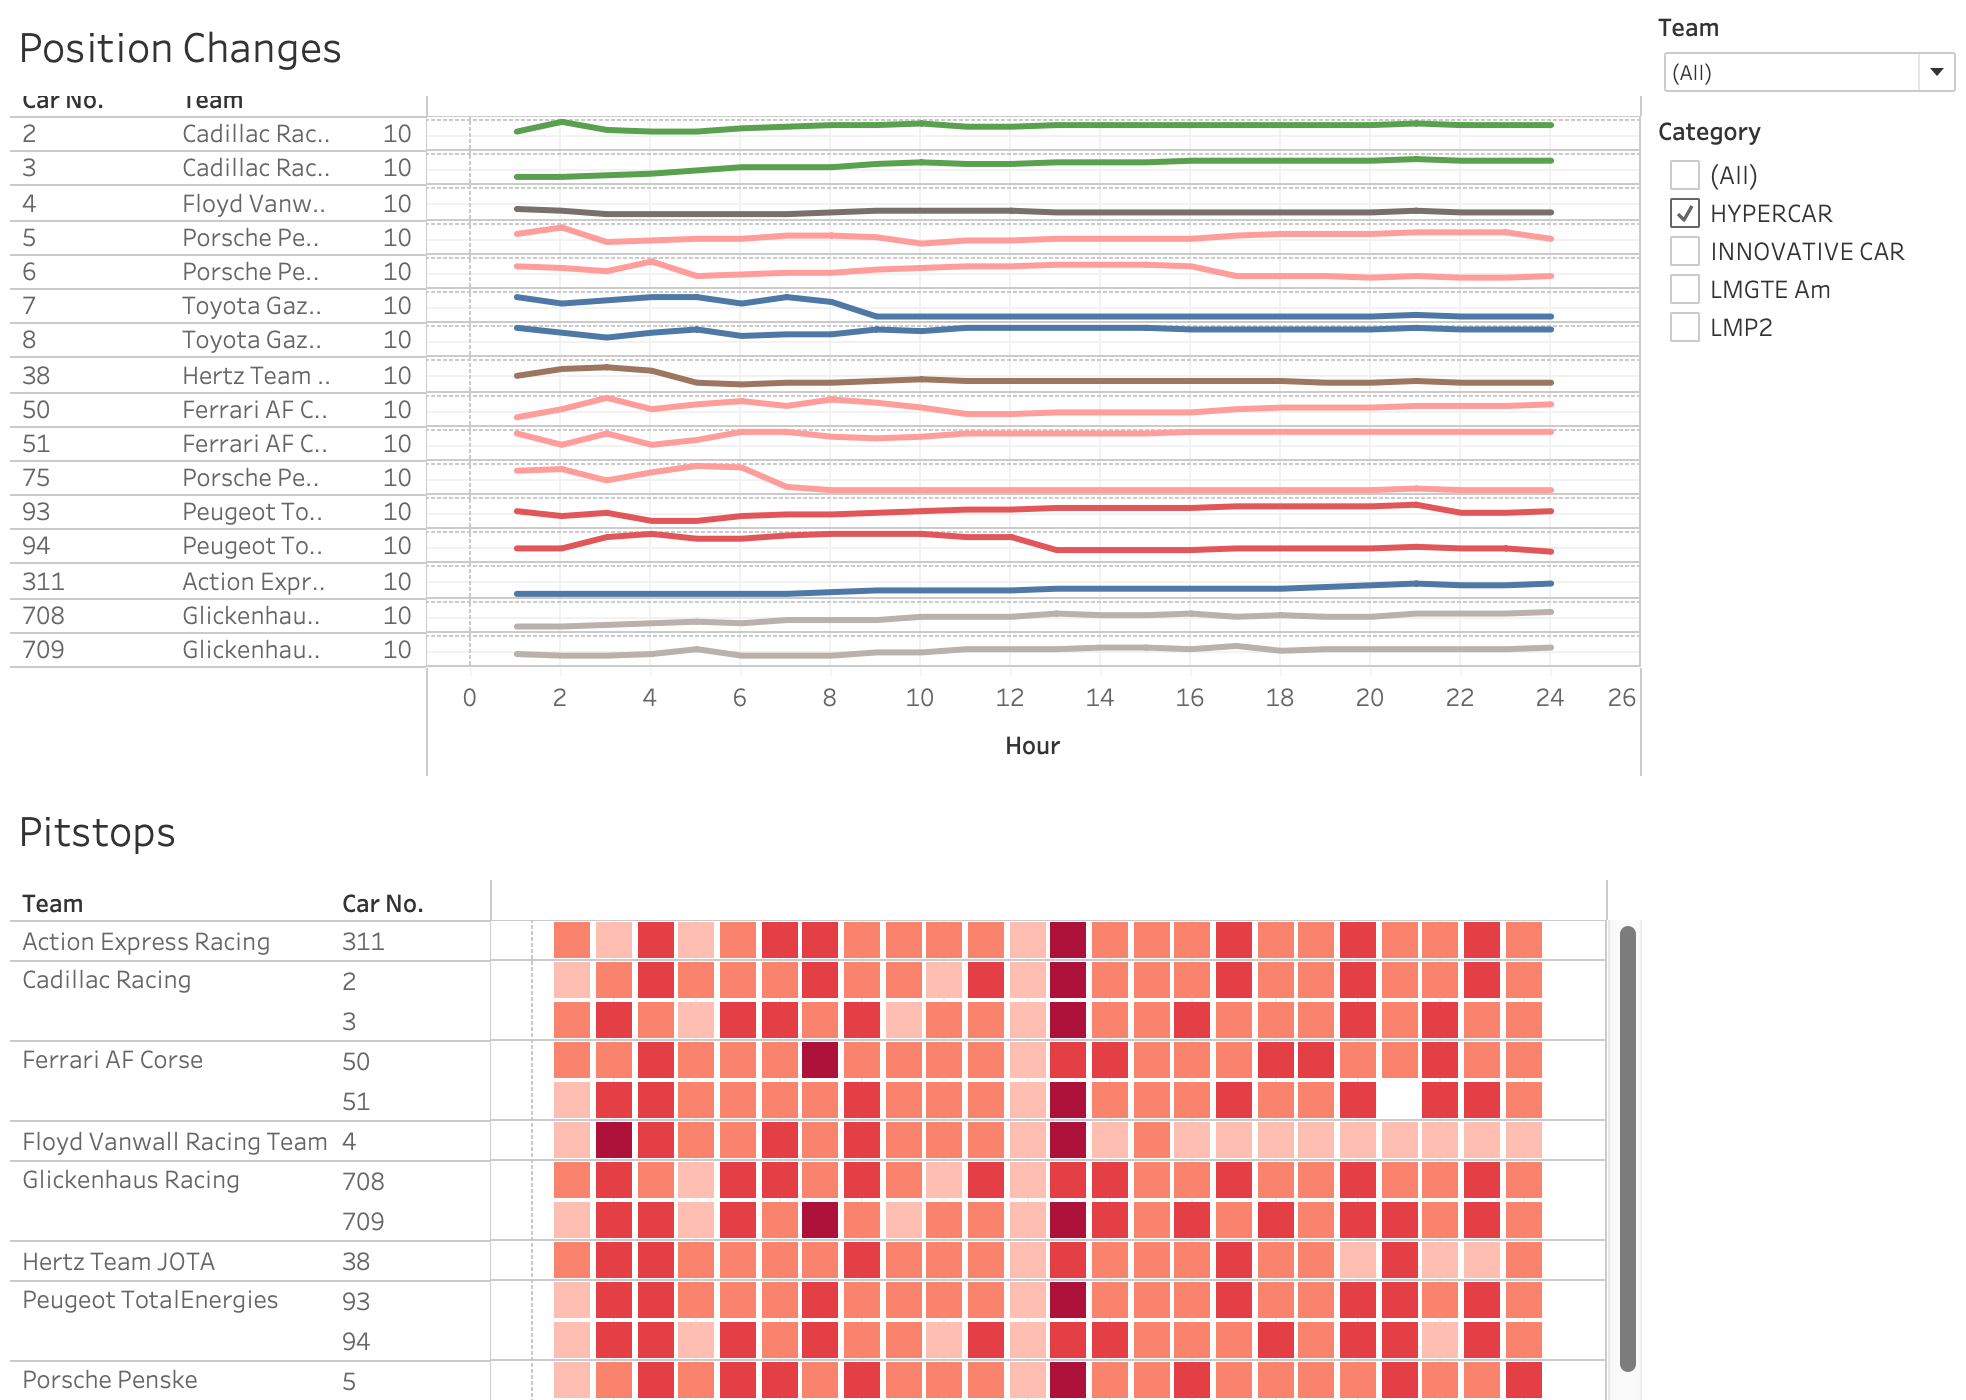

In [119]:
from IPython.display import HTML
import base64

with open('pit_stop_strategy.png', 'rb') as f:
    img_data = base64.b64encode(f.read()).decode()

HTML(f'''
<a href="https://public.tableau.com/shared/YR9MNFFHM" target="_blank">
  <img src="data:image/png;base64,{img_data}" width="1100"/>
  <br><i>Click to view interactive version</i>
</a>
''')

In [120]:
# Act 2: Best Lap Times by Hour
# Track each car's best lap time progression throughout the race
laptime_df = df[['Hour', 'Car No.', 'Team', 'Drivers', 'Car', 
                  'Category', 'Best LapTime (s)', 'Best Lap Kph']].copy()

# Drop rows where Best LapTime is missing
laptime_df = laptime_df.dropna(subset=['Best LapTime (s)'])

print("Best Lap Time Data")
print(f"Shape: {laptime_df.shape}")
print(f"\nFastest overall lap times:")
print(laptime_df.nsmallest(10, 'Best LapTime (s)')[
    ['Hour', 'Car No.', 'Team', 'Drivers', 'Best LapTime (s)', 'Best Lap Kph']
].to_string())

# Export for Tableau
laptime_df.to_csv('hourly_laptimes.csv', index=False)
print("\nExported to hourly_laptimes.csv")

Best Lap Time Data
Shape: (1485, 8)

Fastest overall lap times:
      Hour  Car No.                 Team                              Drivers  Best LapTime (s)  Best Lap Kph
1368    23       50     Ferrari AF Corse    A. FUOCO / M. MOLINA / N. NIELSEN             207.0         237.0
1429    24       50     Ferrari AF Corse    A. FUOCO / M. MOLINA / N. NIELSEN             207.2         236.7
1060    18       50     Ferrari AF Corse    A. FUOCO / M. MOLINA / N. NIELSEN             207.4         236.5
1122    19       50     Ferrari AF Corse    A. FUOCO / M. MOLINA / N. NIELSEN             207.4         236.5
1184    20       50     Ferrari AF Corse    A. FUOCO / M. MOLINA / N. NIELSEN             207.4         236.5
1245    21       50     Ferrari AF Corse    A. FUOCO / M. MOLINA / N. NIELSEN             207.4         236.5
1306    22       50     Ferrari AF Corse    A. FUOCO / M. MOLINA / N. NIELSEN             207.4         236.5
1302    22        8  Toyota Gazoo Racing  S. BUEMI / B. 


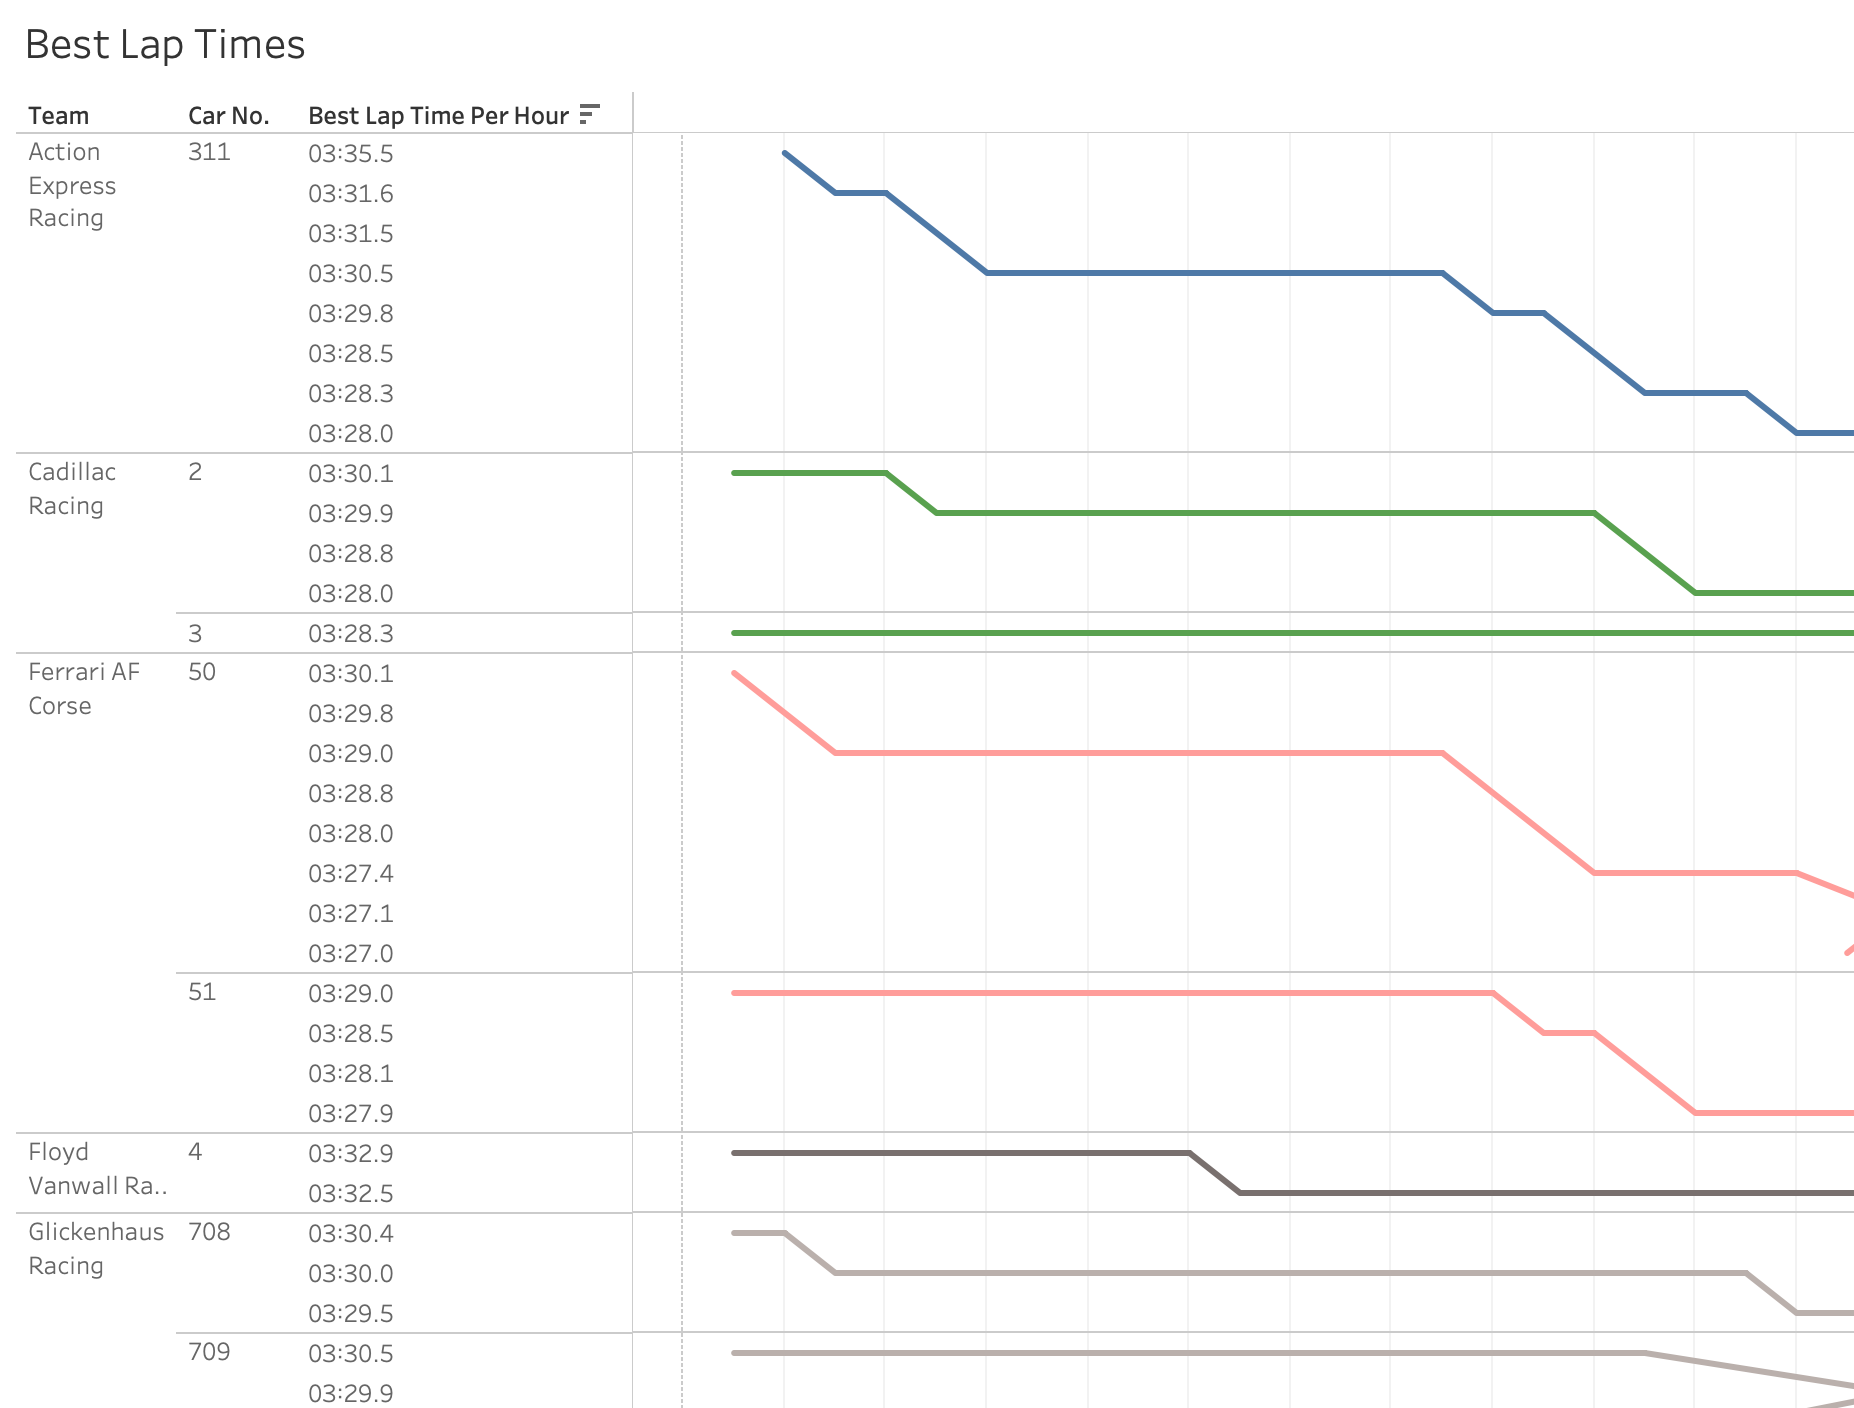

In [121]:
from IPython.display import HTML
import base64

with open('best_lap_times.png', 'rb') as f:
    img_data = base64.b64encode(f.read()).decode()

HTML(f'''
<a href="https://public.tableau.com/shared/TXT84QP96" target="_blank">
  <img src="data:image/png;base64,{img_data}" width="1100"/>
  <br><i>Click to view interactive version</i>
</a>
''')

## Act 2 — Hour by Hour Findings

**Ferrari's Late Race Push:**
Car #50 (Ferrari AF Corse, Fuoco/Molina/Nielsen) improved its best lap time consistently 
throughout the entire race, dropping from 03:30.2 in Hour 1 down to 03:27.0 in Hour 23 —
a remarkable 3+ second improvement over 23 hours. This suggests the team managed the car 
conservatively early on before pushing hard as the race reached its conclusion. Car #50 set 
its fastest lap of 03:27.0 on Lap 306 in Hour 23, slowing only slightly to 03:27.2 in the final hour.

**Understanding the Lap Time Data:**
Best lap times in this dataset are cumulative, once a car sets its best lap it remains flat 
until a faster lap is recorded. This is why many lines plateau for extended periods before 
dropping to a new best, reflecting the natural rhythm of a 24 hour race.

---
# Act 3

Act 3 examines who crossed the finish line, who didn't make it, and the remarkable circumstances that defined the closing hours. With Ferrari and Toyota separated by just 82 seconds after a full day of racing, the 2023 24 Hours of Le Mans delivered a finish for the history books.

---

In [122]:
# Act 3
# Final Standings
# Filter to Hour 24 only — this is the end of race snapshot
final_standings = df[df['Hour'] == 24].copy()

# Rank by laps completed, using total time as tiebreaker
final_standings['Final Position'] = final_standings.sort_values(
    by=['Laps', 'Total Time'],
    ascending=[False, True]
).reset_index(drop=True).index + 1

print("Final Standings")
print(f"Cars still running at Hour 24: {len(final_standings)}")
print(f"\nTop 10 overall:\n")
print(final_standings.nsmallest(10, 'Final Position')[
    ['Final Position', 'Car No.', 'Team', 'Drivers', 'Car', 'Category', 'Laps', 'Total Time', 'Pitstops']
].to_string())

# Export
final_standings.to_csv('final_standings.csv', index=False)
print("\nExported to final_standings.csv")

# Retirements
# Find the first hour each car appeared as 'Retired' 
# Previously used keep='last' which incorrectly showed all retirements at the end of the race
retired = df[df['Status'] == 'Retired'].copy()
retired = retired.sort_values('Hour').drop_duplicates(subset='Car No.', keep='first')

print(f"\nRetirements")
print(f"Retired cars: {len(retired)}")
print(retired[['Hour', 'Car No.', 'Team', 'Car', 'Category']].sort_values('Hour').to_string())

# Export
retired.to_csv('retired_cars.csv', index=False)
print("\nExported to retired_cars.csv")

Final Standings
Cars still running at Hour 24: 61

Top 10 overall:

      Final Position  Car No.                       Team                                    Drivers                  Car  Category  Laps Total Time  Pitstops
1425               1       51           Ferrari AF Corse  A. PIER GUIDI / J. CALADO / A. GIOVINAZZI         Ferrari 499P  HYPERCAR   342   00:00:18        30
1426               2        8        Toyota Gazoo Racing        S. BUEMI / B. HARTLEY / R. HIRAKAWA  Toyota GR010 HYBRID  HYPERCAR   342   00:01:40        31
1427               3        2            Cadillac Racing         E. BAMBER / A. LYNN / R. WESTBROOK  Cadillac V-Series.R  HYPERCAR   341   00:02:37        29
1428               4        3            Cadillac Racing  S. BOURDAIS / R. VAN DER ZANDE / S. DIXON  Cadillac V-Series.R  HYPERCAR   340   00:02:37        30
1429               5       50           Ferrari AF Corse          A. FUOCO / M. MOLINA / N. NIELSEN         Ferrari 499P  HYPERCAR   337   00:


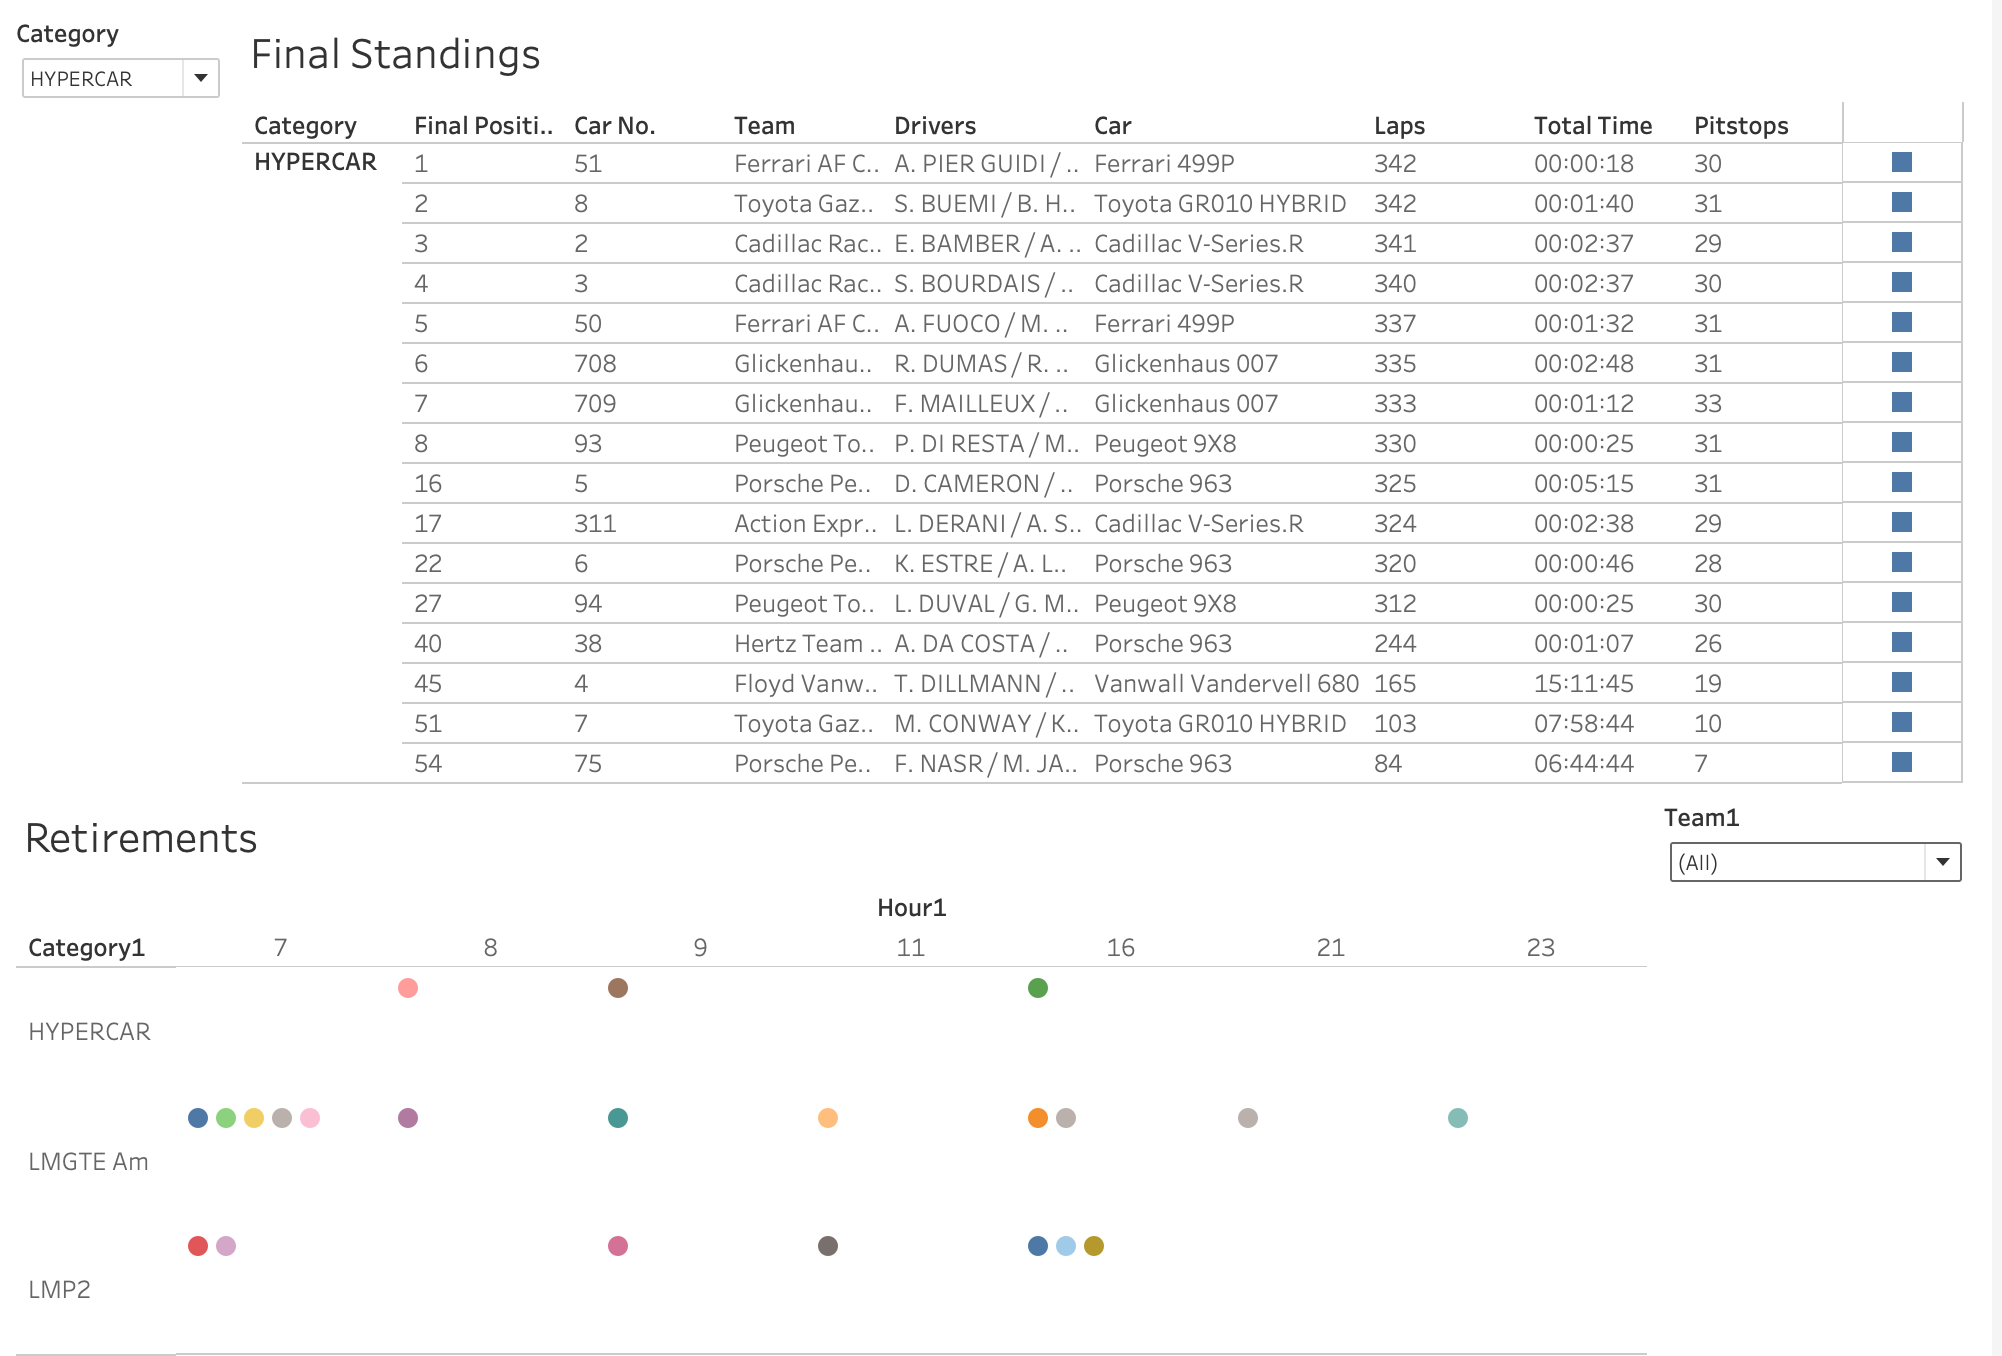

In [123]:
from IPython.display import HTML
import base64

with open('final_dashboard.png', 'rb') as f:
    img_data = base64.b64encode(f.read()).decode()

HTML(f'''
<a href="https://public.tableau.com/views/202324HoursofLeMansFinalDashboard/FinalDashboard" target="_blank">
  <img src="data:image/png;base64,{img_data}" width="1100"/>
  <br><i>Click to view interactive version</i>
</a>
''')

## Act 3 — Final Standings Findings

**An Incredibly Close Finish:**
Car #51 (Ferrari AF Corse, Pier Guidi/Calado/Giovinazzi) won the 2023 24 Hours of Le Mans 
with 342 laps — the same lap count as Car #8 (Toyota Gazoo Racing). The race was decided
purely on time gap, with Ferrari finishing just 1 minute and 22 seconds ahead of Toyota
after 24 hours of racing.

**Notable Finishers:**
Cars #4 (Floyd Vanwall, 165 laps), #7 (Toyota, 103 laps), and #75 (Porsche, 84 laps) completed 
significantly fewer laps than the rest of the field despite being classified as finishers, 
suggesting major incidents or lengthy repairs that cost them substantial track time.

**Reliability by Category:**
- HYPERCAR proved remarkably reliable with only 3 retirements across the entire 24 hours,
  a testament to the engineering quality of the top class
- LMGTE Am suffered the most attrition of any category, with retirements spread throughout
  the race and a particularly brutal **Hour 7** where five cars retired simultaneously
- LMP2 retirements clustered notably around **Hours 7 and 15**, suggesting these were
  the most challenging periods of the race for that class

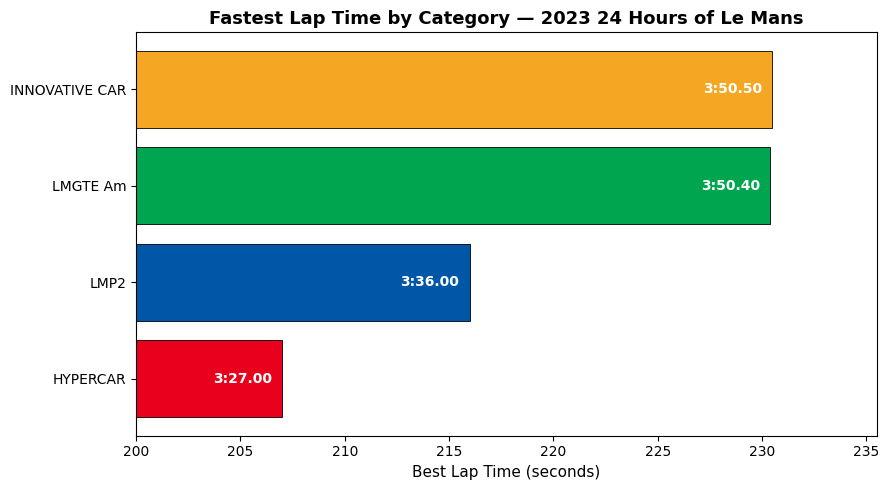

      Category  Best LapTime (s)
      HYPERCAR             207.0
          LMP2             216.0
      LMGTE Am             230.4
INNOVATIVE CAR             230.5


In [126]:
import matplotlib.pyplot as plt
import numpy as np

# Best Lap Time by Category (Bar Chart) 
# Compare average best lap times across categories 

category_laptimes = (
    df.groupby('Category')['Best LapTime (s)']
    .min()
    .reset_index()
    .sort_values('Best LapTime (s)')
)

category_colors = {
    'HYPERCAR':       '#e8001d',
    'LMP2':           '#0057a8',
    'LMGTE Am':       '#00a550',
    'INNOVATIVE CAR': '#f5a623'
}

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    category_laptimes['Category'],
    category_laptimes['Best LapTime (s)'],
    color=[category_colors.get(c, 'gray') for c in category_laptimes['Category']],
    edgecolor='black', linewidth=0.6
)

# Annotate each bar with the formatted lap time
for bar, val in zip(bars, category_laptimes['Best LapTime (s)']):
    mins = int(val // 60)
    secs = val % 60
    ax.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height() / 2,
            f'{mins}:{secs:05.2f}', va='center', ha='right',
            color='white', fontweight='bold', fontsize=10)

ax.set_xlabel('Best Lap Time (seconds)', fontsize=11)
ax.set_title('Fastest Lap Time by Category — 2023 24 Hours of Le Mans',
             fontsize=13, fontweight='bold')
ax.set_xlim(200, category_laptimes['Best LapTime (s)'].max() + 5)

plt.tight_layout()
plt.savefig('laptime_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print(category_laptimes.to_string(index=False))

## Category Lap Time Findings

**Performance Hierarchy by Class:**
The bar chart illustrates the clear performance gap between Le Mans' four categories.
Hypercars set the fastest laps of the race (averaging 3:27). LMP2 cars (averaging 3:37) run without hybrid systems
and on a spec platform, producing a consistent but distinctly slower class. LMGTE Am (~3:51)
are GT-spec grand tourers — heavier and less aerodynamically extreme by design.

Rather than running a regression across categories, this comparison is intentionally presented
as a bar chart. The Hypercar class operates under strict power regulations that cap all cars
at ~500 kW, meaning variance *within* the top class reflects aerodynamics, tyres, and
driver skill, not raw horsepower. 

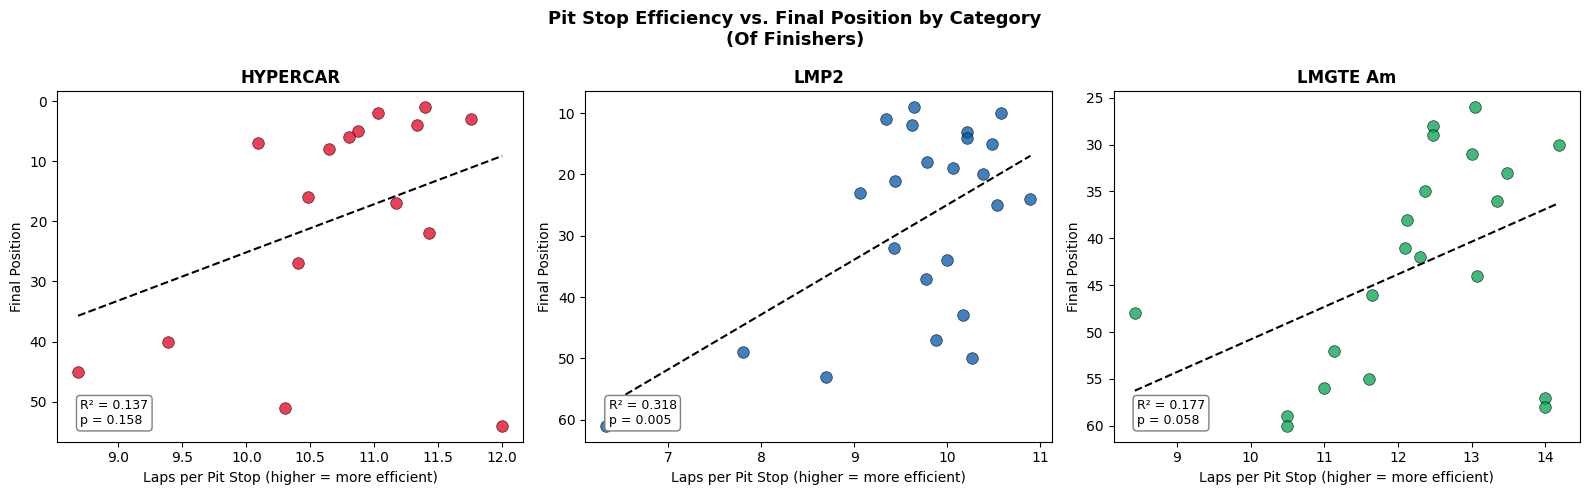

In [125]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Pit Stop Efficiency: Laps Completed per Pit Stop 
# Restrict to finishers only (cars present at Hour 24) to avoid survivorship bias.
# Efficiency = total laps / total pit stops. Higher = more laps per stop = more efficient.

finishers = df[df['Hour'] == 24].copy()
finishers = finishers[finishers['Pitstops'] > 0]  # exclude cars with no recorded pit stops
finishers['Laps per Stop'] = finishers['Laps'] / finishers['Pitstops']

category_colors = {
    'HYPERCAR':       '#e8001d',
    'LMP2':           '#0057a8',
    'LMGTE Am':       '#00a550',
    'INNOVATIVE CAR': '#f5a623'
}

categories = ['HYPERCAR', 'LMP2', 'LMGTE Am']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Pit Stop Efficiency vs. Final Position by Category\n(Of Finishers)',
             fontsize=13, fontweight='bold')

# Merge final position in
finishers = finishers.merge(final_standings[['Car No.', 'Final Position']], on='Car No.')

for ax, cat in zip(axes, categories):
    subset = finishers[finishers['Category'] == cat].dropna()
    x = subset['Laps per Stop']
    y = subset['Final Position']

    slope, intercept, r, p, _ = stats.linregress(x, y)
    r2 = r**2
    line_x = np.linspace(x.min(), x.max(), 100)

    ax.scatter(x, y, color=category_colors[cat], alpha=0.75,
               edgecolors='black', linewidths=0.5, s=70)
    ax.plot(line_x, slope * line_x + intercept,
            color='black', linewidth=1.5, linestyle='--')

    ax.set_title(cat, fontweight='bold')
    ax.set_xlabel('Laps per Pit Stop (higher = more efficient)')
    ax.set_ylabel('Final Position')
    ax.invert_yaxis()
    ax.annotate(f'R² = {r2:.3f}\np = {p:.3f}',
                xy=(0.05, 0.05), xycoords='axes fraction', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))

plt.tight_layout()
plt.savefig('pitstop_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

## Pit Stop Efficiency Findings

**Laps per Pit Stop vs. Final Position (Finishers Only):**
This regresssion is restricted to cars that completed all 24 hours.

A negative correlation (where it appears) suggests that more efficient teams, those who
extracted more laps from each stint, tended to finish higher within their class. This is
consistent with endurance racing logic: unnecessary pit stops cost track position, and
teams that maximised stint length without sacrificing tyre or fuel performance gained a
strategic edge.

Note that R² values are modest across all categories, which is expected, finishing position
in a 24-hour race is determined by many factors beyond pit strategy alone. The relationship
is suggestive rather than deterministic.

---
## Conclusion

The 2023 24 Hours of Le Mans is more than a race, it's a 24-hour experiment in engineering,
strategy, and endurance, and the data tells that story remarkably well.

From the starting grid, the field was defined by contrast: factory-backed Hypercars at the
pinnacle of motorsport technology sharing the same circuit as privateer LMP2 and LMGTE Am
teams racing on a fraction of the budget. That contrast played out across every hour of the race.

The category lap time comparison made the performance hierarchy stand out. Hypercars lapped
Circuit de la Sarthe nearly 10 seconds faster than LMP2 cars and over 20 seconds faster than
LMGTE Am machinery. That's a gap that reflects not just power, but aerodynamic philosophy, tyre
specification, and decades of accumulated engineering. Crucially, within the Hypercar class
itself, all manufacturers are regulated to the same ~670hp output, meaning those fractional
differences in lap time came down to aero efficiency, tyre management, and driver skill rather
than raw horsepower.

The pit stop efficiency analysis reframed how strategy shapes results. By restricting to
finishers only and measuring laps completed per pit stop, the data showed that teams who
extracted the most from each stint tended to finish higher within their class. The relationship
is modest, endurance racing is too complex for any single metric to explain finishing position
cleanly, but the direction is consistent: wasted pit stops cost track position.

The reliability picture added another dimension. LMGTE Am suffered the most attrition of any
category, with a particularly brutal Hour 7 wiping out four cars simultaneously. Hypercar, by
contrast, saw only three retirements across the entire 24 hours, a testament to the engineering
depth of the factory programs at the front of the field.

Nowhere did all of these threads converge more dramatically than the finish. Ferrari Car #51
and Toyota Car #8 crossed the line having completed the exact same number of laps — 342 —
separated by just 1 minute and 22 seconds after 24 hours of racing. It was the finest possible
illustration of what endurance racing is: not the fastest car winning, but the best-managed one.

---

## Technologies Used & Credits

**Claude Sonnet 4.6** was utilized throughout for assistance in generating code and visualizations. 

**Python Libraries:**
- **Pandas** — data loading, cleaning, analysis, and CSV exports.
- **BeautifulSoup** — web scraping car descriptions and race overview from Wikipedia.
- **Requests** — fetching web pages for scraping.
- **Warnings** — suppressing known and documented warnings in the code.
- **Regex (re)** — stripping Wikipedia citation brackets from scraped text.
- **IPython.display** — embedding Tableau visualizations.
- **Matplotlib** — generating a category lap time bar chart and pit stop efficiency scatter plots to visualize performance differences and strategic patterns across the field.

**Visualization:**
- **Tableau Desktop** — building all interactive dashboards and visualizations.
- **Tableau Public** — publishing and hosting dashboards for embedding.

**Data Sources**
- **2023 24 Hours of Le Mans** hourly race data, originally pulled from the official 
  24 Hours of Le Mans website.
- **Wikipedia** — supplementary car descriptions and race overview scraped via BeautifulSoup.